<a href="https://colab.research.google.com/github/QuangDuy1512/ecommerce-behavior-analysis/blob/main/notebooks/03_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tải dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/drive/MyDrive/personal_projects/analysis_dataset.csv"
)

print(df.shape)

(674987, 10)


## Kiểm tra chất lượng dữ liệu

In [ ]:
print(df.info())

display(df.head())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674987 entries, 0 to 674986
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     674987 non-null  object 
 1   event_type     674987 non-null  object 
 2   product_id     674987 non-null  int64  
 3   category_id    674987 non-null  int64  
 4   category_code  604100 non-null  object 
 5   brand          593645 non-null  object 
 6   price          674987 non-null  float64
 7   user_id        674987 non-null  int64  
 8   user_session   674987 non-null  object 
 9   HourKey        674987 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 51.5+ MB
None


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,HourKey
0,2019-12-07 18:52:21+00:00,view,20100170,2232732110089618156,apparel.trousers,nika,88.81,575358172,d860e8d1-6364-4117-a85b-cf467df2e05f,2019-12-07 18
1,2019-12-29 10:30:43+00:00,view,12400194,2232732092087664982,electronics.audio.microphone,crown,84.94,542328720,e345748e-173f-4500-b300-64d230b07e6c,2019-12-29 10
2,2019-12-18 18:43:25+00:00,view,4300183,2053013552385491165,appliances.sewing_machine,electrolux,90.07,514113327,35207372-6743-4834-8179-5488ca42b5aa,2019-12-18 18
3,2019-12-02 10:15:35+00:00,view,4000175,2053013566142809077,construction.tools.generator,polaris,77.20,576024739,6ec31ca0-bcab-4a66-ab0d-8ddd96e1ae2b,2019-12-02 10
4,2019-12-16 23:31:13+00:00,view,31501161,2232732115617710964,apparel.shoes.keds,luminarc,107.85,588048847,0b624f68-eaa0-4a5e-a1df-5af55044e73c,2019-12-16 23


,product_id,category_id,price,user_id
count,6.749870e+05,6.749870e+05,674987.000000,6.749870e+05
mean,1.763862e+07,2.179162e+18,274.499753,5.481376e+08
std,2.732872e+07,8.162037e+16,347.299275,2.859377e+07
min,1.000894e+06,2.053014e+18,0.000000,2.951588e+07
25%,1.005267e+06,2.053014e+18,61.730000,5.188552e+08
50%,5.300032e+06,2.232732e+18,154.420000,5.469324e+08
75%,2.140391e+07,2.232732e+18,332.010000,5.740007e+08
max,1.000642e+08,2.232732e+18,2574.070000,5.954143e+08


## Phân tích và xử lý các giá trị thiếu

### Phân tích giá trị thiếu

In [ ]:
missing = (df.isna().sum().sort_values(ascending=False))

missing_pct = (missing / len(df) * 100)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_%": missing_pct
})

missing_report

,Missing_Count,Missing_%
brand,81342,12.050899
category_code,70887,10.501980
event_type,0,0.000000
event_time,0,0.000000
category_id,0,0.000000
product_id,0,0.000000
price,0,0.000000
user_id,0,0.000000
user_session,0,0.000000
HourKey,0,0.000000


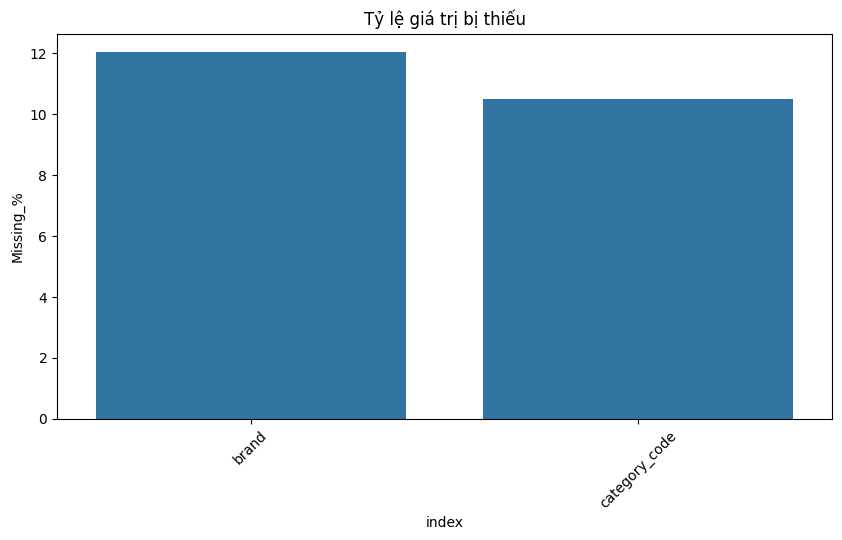

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
missing_report = (
    missing_report[missing_report["Missing_Count"] > 0]
)
plt.figure(figsize=(10,5))
sns.barplot(
    data=missing_report.reset_index(),
    x="index",
    y="Missing_%"
)
plt.xticks(rotation=45)
plt.title("Tỷ lệ giá trị bị thiếu")
plt.show()

**Nhận xét:**
- Thực trạng: Trường brand thiếu 12.05% và category_code thiếu 10.5%.

- Giải pháp đề xuất: Vì đây là các biến phân loại (Categorical) cấu thành nên đặc trưng sản phẩm, việc xóa bỏ (>20% tổng số dòng bị ảnh hưởng) sẽ làm mất đi lượng lớn dữ liệu hành vi.


### Xử lý giá trị thiếu

In [ ]:
# Thay thế các giá trị NaN bằng chuỗi "Unknown"
df["brand"] = (df["brand"].fillna("Unknown"))

# Thay thế bằng chuỗi "Unknown.Unknown" trước khi tiến hành tách chuỗi ở bước sau để đảm bảo tính đồng nhất.
df["category_code"] = (df["category_code"].fillna("Unknown.Unknown"))

df["user_session"] = (df["user_session"].fillna("MissingSession"))

In [ ]:
# Kiểm tra
df[["brand","category_code","user_session"]].isna().sum()

,0
brand,0
category_code,0
user_session,0


## Phân tích và xử lý dữ liệu trùng lặp

In [ ]:
# Đếm Exact Duplicate
exact_duplicates = (df.duplicated().sum())
print(exact_duplicates)

# Xóa Exact Duplicate
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before-after}")


32
Removed 32


In [ ]:
# Kiểm tra Business Duplicate
business_duplicates = (
    df.duplicated(
        subset=[
            "event_time",
            "event_type",
            "product_id",
            "user_id"
        ]
    )
    .sum()
)
print(business_duplicates)

# Xử lý Business Duplicate
before = len(df)
df = df.drop_duplicates(
    subset=[
        "event_time",
        "event_type",
        "product_id",
        "user_id"
    ],
    keep="first"
)
er = len(df)
print(f"Removed {before-after}")

2
Removed 0


## Làm sạch Datetime

In [ ]:
# Kiểm tra kiểu dữ liệu
df["event_time"].dtype

dtype('O')

In [ ]:
# Chuyển đổi datetime
df["event_time"] = pd.to_datetime(df["event_time"])

In [ ]:
print(df["event_time"].min())
print(df["event_time"].max())

2019-12-01 00:00:12+00:00
2019-12-31 23:59:27+00:00


## Phân tích chất lượng giá cả

In [ ]:
# Kiểm tra giá trị bất thường
df["price"].describe()

,price
count,674953.000000
mean,274.501358
std,347.303590
min,0.000000
25%,61.730000
50%,154.420000
75%,332.010000
max,2574.070000


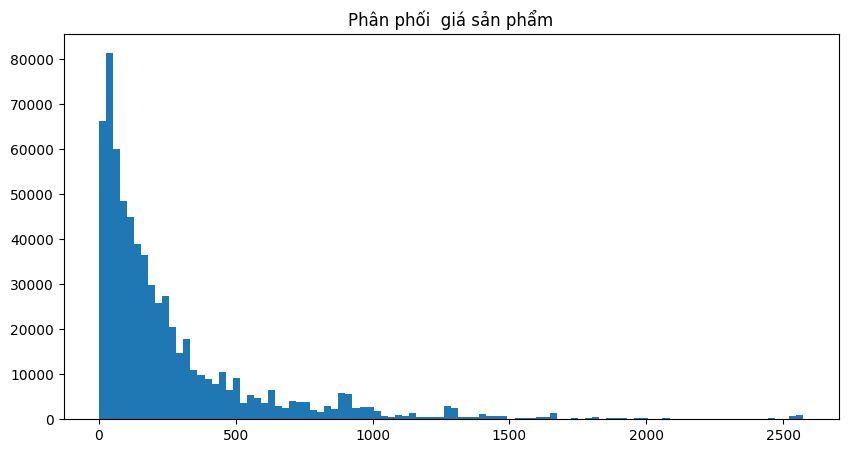

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df["price"],bins=100)
plt.title("Phân phối  giá sản phẩm")
plt.show()

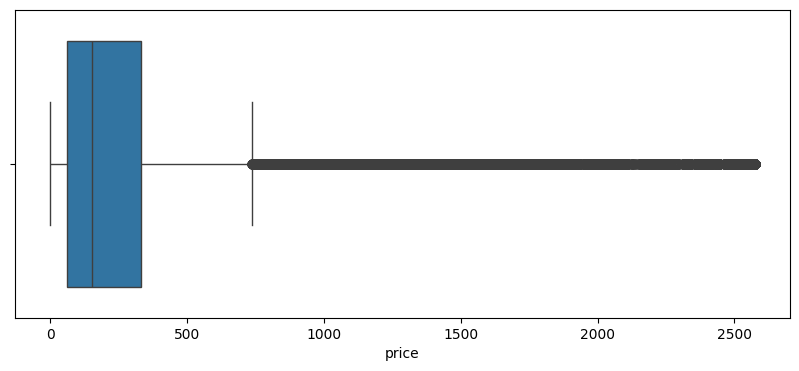

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["price"])
plt.show()

Biểu đồ hộp cho thấy tồn tại nhiều giá trị nằm ngoài ngưỡng IQR. Tuy nhiên đây chủ yếu là các sản phẩm thuộc phân khúc giá cao (premium products) như thiết bị điện tử và không được xem là dữ liệu lỗi. Do đó các giá trị này được giữ lại để đảm bảo phản ánh đúng hành vi thị trường.

In [ ]:
# Giá trị giá <= 0
invalid_price = (df["price"] <= 0).sum()
print(invalid_price)

604


In [ ]:
df[df["price"] <= 0]["event_type"].value_counts()

,count
event_type,
view,591
cart,13


Phát hiện 604 bản ghi (0.089%) có giá trị price ≤ 0. Đây được xem là dữ liệu không hợp lệ vì giá sản phẩm trên sàn thương mại điện tử không thể bằng hoặc nhỏ hơn 0. Các bản ghi này được loại bỏ nhằm đảm bảo độ chính xác cho các phân tích doanh thu, hành vi mua hàng và mô hình dự báo.

In [ ]:
before = len(df)
df = df[df["price"] > 0]
after = len(df)
print(f"Xóa {before-after} các bản ghi có giá không hợp lệ")

Xóa 604 các bản ghi có giá không hợp lệ


## Làm sạch Category

In [ ]:
# Kiểm tra category
df["category_code"]\
.value_counts()\
.head(20)

,count
category_code,
construction.tools.light,165088
Unknown.Unknown,70809
electronics.clocks,27490
appliances.personal.massager,26423
apparel.shoes,25046
appliances.kitchen.refrigerators,23834
sport.bicycle,23414
appliances.environment.vacuum,14225
computers.peripherals.printer,14042


In [ ]:
# Tách Category
split_category = (
    df["category_code"]
    .str.split(
        ".",
        expand=True
    )
)
df["Category"] = (split_category[0])
df["Sub_Category"] = (split_category[1])
df["Product_Group"] = (split_category[2])
df["Sub_Category"] = (df["Sub_Category"].fillna("Unknown"))

df["Product_Group"] = (df["Product_Group"].fillna("Unknown"))
df[["category_code","Category","Sub_Category","Product_Group"]].head()

,category_code,Category,Sub_Category,Product_Group
0,apparel.trousers,apparel,trousers,Unknown
1,electronics.audio.microphone,electronics,audio,microphone
2,appliances.sewing_machine,appliances,sewing_machine,Unknown
3,construction.tools.generator,construction,tools,generator
4,apparel.shoes.keds,apparel,shoes,keds


## Event Validation

In [ ]:
event_counts = (df["event_type"].value_counts())
event_counts

,count
event_type,
view,628696
cart,33937
purchase,11716


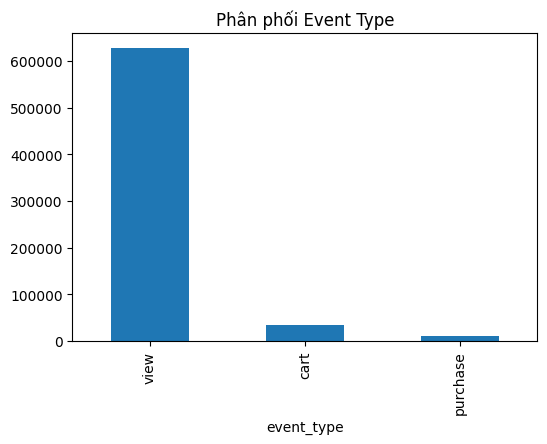

In [ ]:
plt.figure(figsize=(6,4))
event_counts.plot(kind="bar")
plt.title("Phân phối Event Type")
plt.show()

## Báo cáo chất lượng dữ liệu cuối cùng

In [ ]:
print("="*60)
print("Rows:",len(df))
print("Products:",df["product_id"].nunique())
print("Users:",df["user_id"].nunique())
print("Brands:",df["brand"].nunique())
print("Missing Values:")
print( df.isna().sum().sum())
print("="*60)

Rows: 674349
Products: 80085
Users: 489362
Brands: 3528
Missing Values:
0


In [ ]:
output_path = ("/content/drive/MyDrive/personal_projects/clean_dataset.csv")
df.to_csv(output_path,index=False)
print(f"Saved: {output_path}")

Saved: /content/drive/MyDrive/personal_projects/clean_dataset.csv
